# Assignment 1: Sampler Synthesis — Starter Code

This notebook provides baseline implementations of Random Walk Metropolis-Hastings and HMC using [BlackJAX](https://blackjax-devs.github.io/blackjax/). Use these as reference points for your novel sampler.

**Your task**: Design, implement, and analyze a novel MCMC sampler. Compare it to these baselines on the benchmark distributions.

In [13]:
!pip install blackjax

import arviz as az
import blackjax
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["font.size"] = 12

---
## Benchmark Distribution: Rosenbrock (Banana)

The Rosenbrock distribution has a curved, narrow ridge that tests how well samplers handle strong correlations and curved geometry. This is challenging because:
- The high-probability region is thin and curved
- Random walk proposals often step off the ridge
- Samplers need to follow the curved geometry efficiently

In [14]:
def log_prob_rosenbrock(theta):
    """Rosenbrock (banana) distribution.

    log p(x, y) ∝ -(1-x)²/20 - (y - x²)²

    This creates a curved, banana-shaped distribution that tests
    how well samplers handle strong correlations and curved geometry.
    """
    x, y = theta[0], theta[1]
    return -0.05 * (1 - x) ** 2 - (y - x**2) ** 2

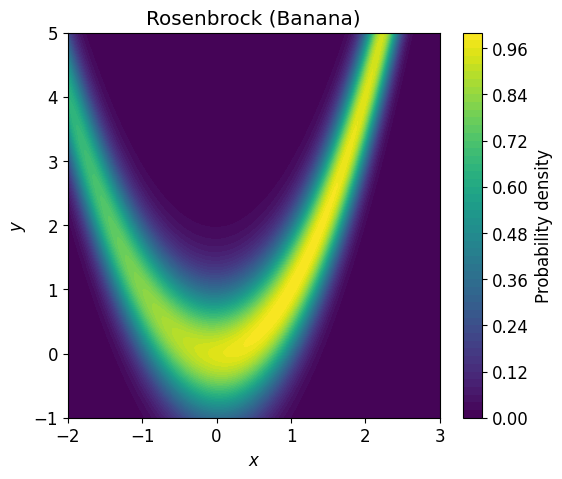

In [15]:
def plot_distribution(log_prob_fn, title, xlim=(-4, 4), ylim=(-4, 4)):
    """Visualize a 2D log probability distribution."""
    x = jnp.linspace(*xlim, 200)
    y = jnp.linspace(*ylim, 200)
    X, Y = jnp.meshgrid(x, y)
    positions = jnp.stack([X.ravel(), Y.ravel()], axis=-1)

    log_probs = jax.vmap(log_prob_fn)(positions).reshape(X.shape)

    plt.figure(figsize=(6, 5))
    plt.contourf(X, Y, jnp.exp(log_probs), levels=50, cmap="viridis")
    plt.colorbar(label="Probability density")
    plt.xlabel(r"$x$")
    plt.ylabel(r"$y$")
    plt.title(title)
    plt.show()


plot_distribution(log_prob_rosenbrock, "Rosenbrock (Banana)", xlim=(-2, 3), ylim=(-1, 5))

---
## Baseline 1: Random Walk Metropolis-Hastings

The simplest MCMC method. Proposes isotropic Gaussian steps — no gradient information.

**Tuning tip:** Target ~23-50% acceptance rate. Higher isn't better — it means steps are too small.

In [16]:
def run_rwmh(key, log_prob_fn, initial_position, sigma, n_samples):
    """Run Random Walk Metropolis-Hastings using BlackJAX.

    Args:
        key: JAX random key
        log_prob_fn: Log probability function
        initial_position: Starting point, shape (D,)
        sigma: Proposal standard deviation (scalar or array)
        n_samples: Number of samples to draw

    Returns:
        samples: Array of shape (n_samples, D)
        acceptance_rate: Fraction of accepted proposals
    """
    # Initialize the sampler with a normal proposal distribution
    rmh = blackjax.additive_step_random_walk(log_prob_fn, blackjax.mcmc.random_walk.normal(sigma))
    initial_state = rmh.init(initial_position)

    # Build the sampling loop
    @jax.jit
    def one_step(state, key):
        state, info = rmh.step(key, state)
        return state, (state.position, info.is_accepted)

    # Run the chain
    keys = jr.split(key, n_samples)
    _, (samples, accepted) = jax.lax.scan(one_step, initial_state, keys)

    return samples, accepted.mean()

---
## Baseline 2: Hamiltonian Monte Carlo (HMC)

Uses gradient information to make informed proposals. Typically much more efficient than random walk.

**Tuning tip:** Target ~65-90% acceptance rate. Tune step_size first, then n_leapfrog.

In [17]:
def run_hmc(key, log_prob_fn, initial_position, step_size, n_leapfrog, n_samples):
    """Run HMC using BlackJAX.

    Args:
        key: JAX random key
        log_prob_fn: Log probability function
        initial_position: Starting point, shape (D,)
        step_size: Leapfrog step size (epsilon)
        n_leapfrog: Number of leapfrog steps per iteration
        n_samples: Number of samples to draw

    Returns:
        samples: Array of shape (n_samples, D)
        acceptance_rate: Fraction of accepted proposals
    """
    # Initialize the sampler (identity mass matrix)
    inverse_mass_matrix = jnp.ones(initial_position.shape[0])
    hmc = blackjax.hmc(
        log_prob_fn,
        step_size=step_size,
        inverse_mass_matrix=inverse_mass_matrix,
        num_integration_steps=n_leapfrog,
    )
    initial_state = hmc.init(initial_position)

    # Build the sampling loop
    @jax.jit
    def one_step(state, key):
        state, info = hmc.step(key, state)
        return state, (state.position, info.acceptance_rate)

    # Run the chain
    keys = jr.split(key, n_samples)
    _, (samples, accepted) = jax.lax.scan(one_step, initial_state, keys)

    return samples, accepted.mean()

---
## Run Baselines on Rosenbrock

In [18]:
key = jr.PRNGKey(42)
key1, key2 = jr.split(key)

initial_pos = jnp.array([0.0, 0.0])
n_samples = 50_000

# Random Walk MH
rwmh_samples, rwmh_acc = run_rwmh(key1, log_prob_rosenbrock, initial_pos, sigma=1.0, n_samples=n_samples)
print(f"RWMH acceptance rate: {rwmh_acc:.2%}")

# HMC
hmc_samples, hmc_acc = run_hmc(
    key2, log_prob_rosenbrock, initial_pos, step_size=0.2, n_leapfrog=10, n_samples=n_samples
)
print(f"HMC acceptance rate: {hmc_acc:.2%}")

RWMH acceptance rate: 10.38%
HMC acceptance rate: 74.78%


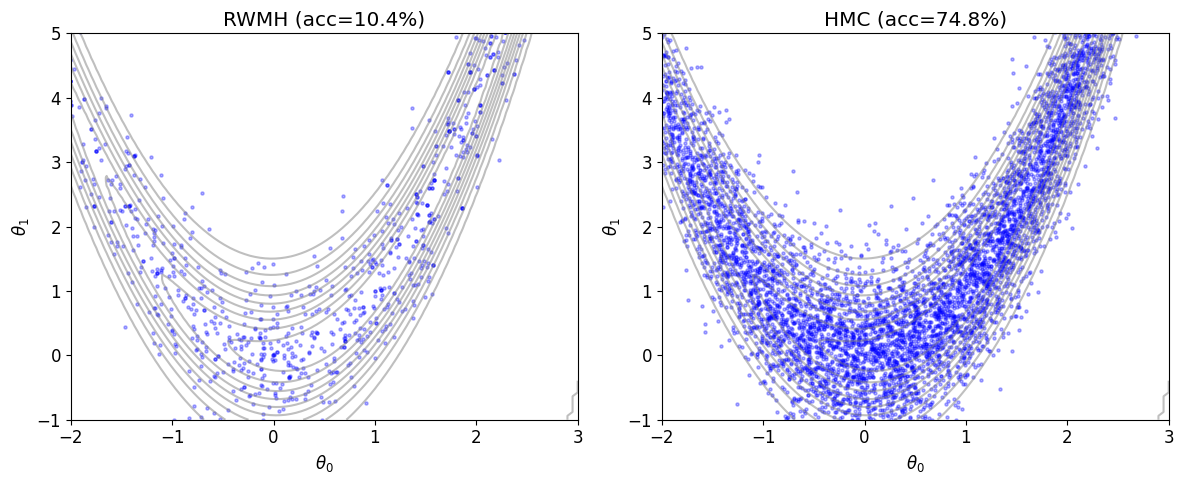

In [19]:
def plot_samples_comparison(samples1, samples2, label1, label2, log_prob_fn, xlim, ylim):
    """Plot samples from two methods side by side."""
    # Compute contours
    x = jnp.linspace(*xlim, 100)
    y = jnp.linspace(*ylim, 100)
    X, Y = jnp.meshgrid(x, y)
    positions = jnp.stack([X.ravel(), Y.ravel()], axis=-1)
    log_probs = jax.vmap(log_prob_fn)(positions).reshape(X.shape)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    for ax, samples, label in zip(axes, [samples1, samples2], [label1, label2]):
        ax.contour(X, Y, jnp.exp(log_probs), levels=10, colors="gray", alpha=0.5)
        ax.scatter(samples[::5, 0], samples[::5, 1], alpha=0.3, s=5, c="blue")
        ax.set_xlabel(r"$\theta_0$")
        ax.set_ylabel(r"$\theta_1$")
        ax.set_title(label)
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)

    plt.tight_layout()
    plt.show()


plot_samples_comparison(
    rwmh_samples,
    hmc_samples,
    f"RWMH (acc={rwmh_acc:.1%})",
    f"HMC (acc={hmc_acc:.1%})",
    log_prob_rosenbrock,
    xlim=(-2, 3),
    ylim=(-1, 5),
)

---
## Diagnostics with ArviZ

[ArviZ](https://python.arviz.org/) provides standard MCMC diagnostics. Key metrics:
- **Acceptance rate**: Too low = proposals too aggressive; too high = proposals too timid
- **Effective Sample Size (ESS)**: How many independent samples you effectively have
- **Trace plots**: Visual check for mixing and stationarity
- **Autocorrelation**: How correlated successive samples are

In [20]:
import numpy as np

def samples_to_inference_data(samples, var_names=None):
    """Convert samples array to ArviZ InferenceData.

    Args:
        samples: Array of shape (n_samples, n_dims)
        var_names: Optional list of variable names

    Returns:
        ArviZ InferenceData object
    """
    if var_names is None:
        var_names = [f"theta_{i}" for i in range(samples.shape[1])]

    # Convert JAX array to numpy array to ensure ArviZ compatibility
    samples_np = np.asarray(samples)

    # ArviZ expects dict of {var_name: array} with shape (n_chains, n_samples)
    data_dict = {name: samples_np[None, :, i] for i, name in enumerate(var_names)}
    return az.from_dict(posterior=data_dict)


def summarize_sampler(samples, name, var_names=None):
    """Print summary statistics and ESS for samples using ArviZ."""
    idata = samples_to_inference_data(samples, var_names)
    print(f"\n=== {name} ===")
    display(az.summary(idata, kind="stats"))
    print("\nEffective Sample Size (ESS):")
    display(az.ess(idata))

In [21]:
# Rosenbrock diagnostics
var_names = ["x", "y"]

rwmh_idata = samples_to_inference_data(rwmh_samples, var_names)
hmc_idata = samples_to_inference_data(hmc_samples, var_names)

# Summary statistics (mean, sd, ESS)
summarize_sampler(rwmh_samples, "RWMH — Rosenbrock", var_names)
summarize_sampler(hmc_samples, "HMC — Rosenbrock", var_names)


=== RWMH — Rosenbrock ===


,mean,sd,hdi_3%,hdi_97%
x,5.555,2.141,0.706,8.087
y,35.447,17.237,-0.248,58.602



Effective Sample Size (ESS):


<xarray.Dataset> Size: 16B
Dimensions:  ()
Data variables:
    x        float64 8B 1.545
    y        float64 8B 1.544
Attributes:
    created_at:     2026-10-05T08:54:59.816742+00:00
    arviz_version:  0.22.0


=== HMC — Rosenbrock ===


,mean,sd,hdi_3%,hdi_97%
x,0.456,2.202,-3.390,4.018
y,4.970,5.012,-0.379,15.324



Effective Sample Size (ESS):


<xarray.Dataset> Size: 16B
Dimensions:  ()
Data variables:
    x        float64 8B 41.64
    y        float64 8B 93.39
Attributes:
    created_at:     2026-10-05T08:55:01.663705+00:00
    arviz_version:  0.22.0

RWMH Trace Plots:


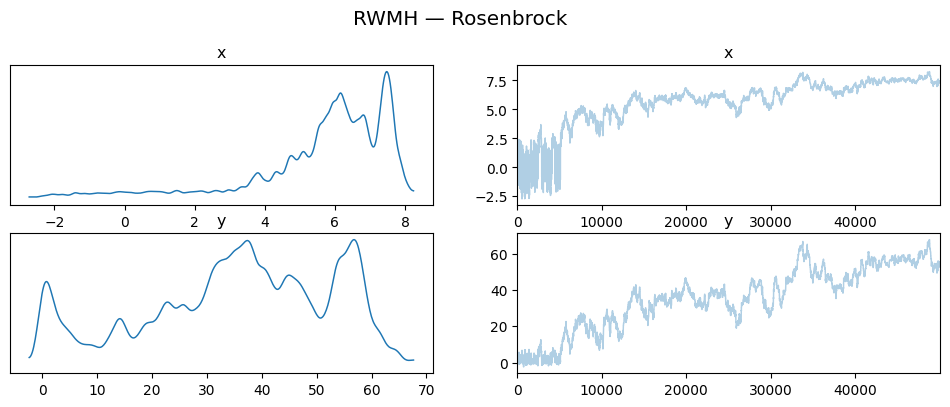


HMC Trace Plots:


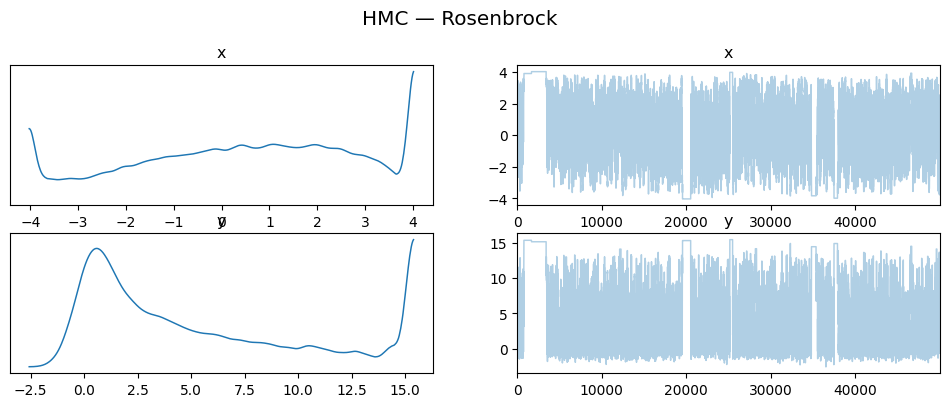

In [22]:
# Trace plots — Rosenbrock
print("RWMH Trace Plots:")
az.plot_trace(rwmh_idata)
plt.suptitle("RWMH — Rosenbrock", y=1.02)
plt.show()

print("\nHMC Trace Plots:")
az.plot_trace(hmc_idata)
plt.suptitle("HMC — Rosenbrock", y=1.02)
plt.show()


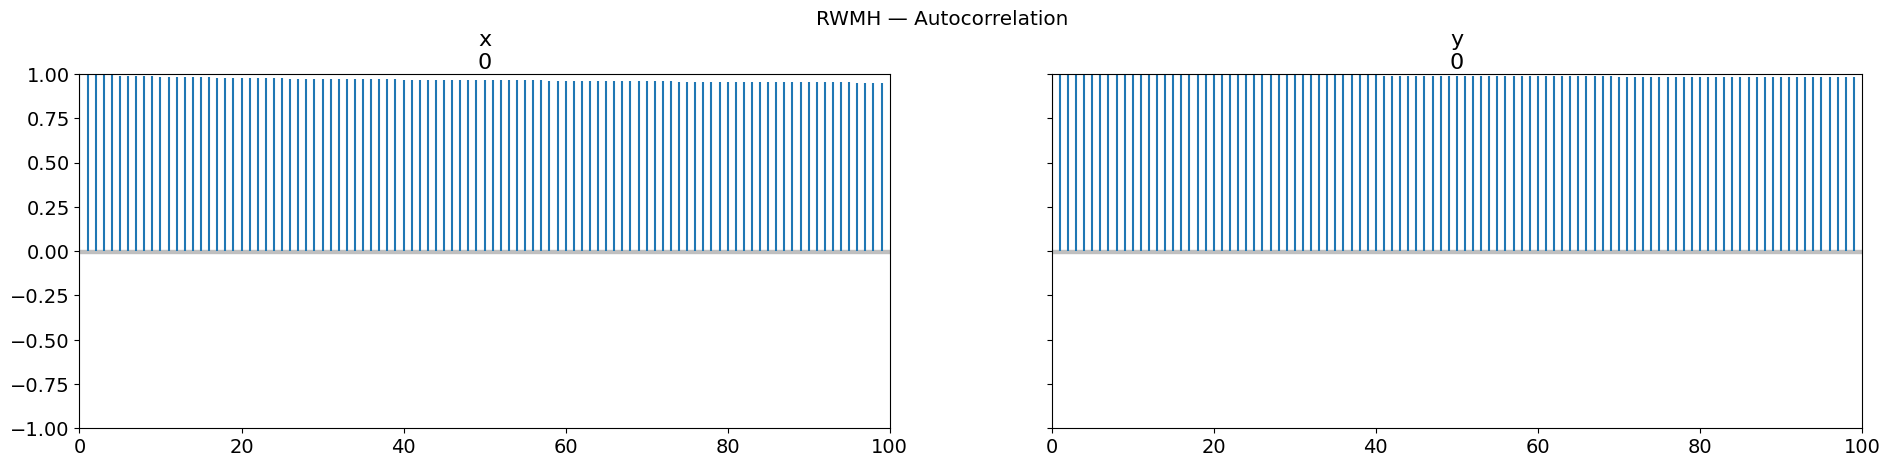

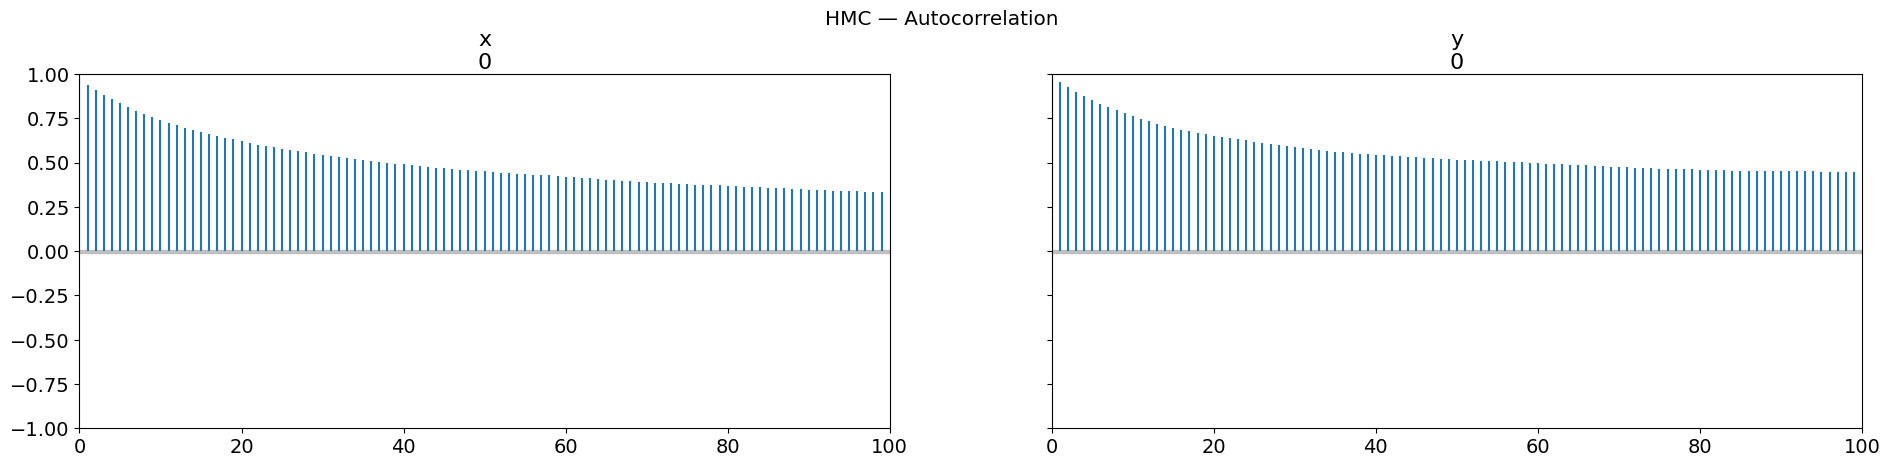

In [23]:
# Autocorrelation — Rosenbrock
az.plot_autocorr(rwmh_idata)
plt.suptitle("RWMH — Autocorrelation", y=1.02)
plt.show()

az.plot_autocorr(hmc_idata)
plt.suptitle("HMC — Autocorrelation", y=1.02)
plt.show()


---
## Discussion: Why Does RWMH Struggle Here?

Look carefully at the results above. You might notice something surprising: RWMH has *lower* autocorrelation than HMC, yet HMC explores the distribution much better. What's going on?

**The issue is local vs. global mixing.** RWMH with isotropic proposals faces a dilemma on curved distributions like the Rosenbrock:
- If the proposal scale is small enough to stay on the narrow ridge, it can't move far along the banana
- If the proposal scale is large enough to explore, most proposals step off the ridge and get rejected

So RWMH ends up jittering locally — samples decorrelate quickly *within* its local neighborhood, but it never traverses the full banana. Low autocorrelation doesn't mean good exploration!

**HMC uses gradients to follow the curve.** It makes long, coherent moves along the ridge without stepping off. The high autocorrelation is just because consecutive samples are along the same trajectory — but they're actually covering the full posterior.

This is exactly the kind of geometry where HMC shines, and one of the main motivations for gradient-based samplers.

---
## Benchmark Distribution 2: Neal's Funnel

Neal's Funnel is a hierarchical distribution that varies dramatically in scale across the space. The narrow "neck" of the funnel is notoriously difficult for fixed step-size samplers.

$$v \sim \mathcal{N}(0, 9), \quad x \sim \mathcal{N}(0, e^v)$$

This means:
- When $v$ is large and positive, $x$ can vary widely
- When $v$ is large and negative, $x$ is tightly constrained near 0
- A single step size can't work well everywhere

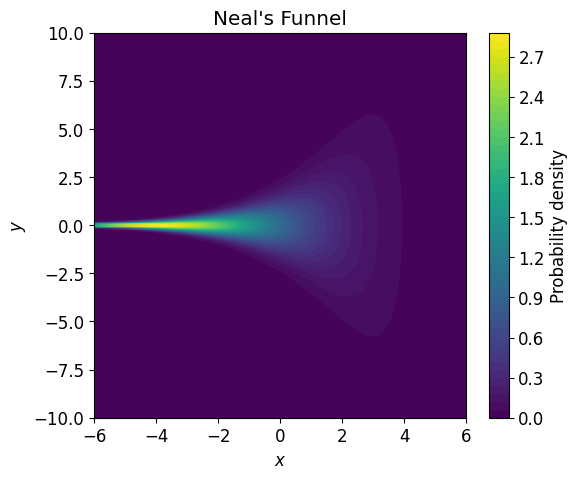

In [24]:
def log_prob_funnel(theta):
    """Neal's Funnel distribution.

    v ~ N(0, 9)
    x ~ N(0, exp(v))

    This creates a funnel shape where the scale of x depends on v.
    The narrow neck (small v) is very hard to sample.
    """
    v, x = theta[0], theta[1]
    log_p_v = -0.5 * v**2 / 9  # v ~ N(0, 9)
    log_p_x_given_v = -0.5 * x**2 * jnp.exp(-v) - 0.5 * v  # x ~ N(0, exp(v))
    return log_p_v + log_p_x_given_v


plot_distribution(log_prob_funnel, "Neal's Funnel", xlim=(-6, 6), ylim=(-10, 10))

In [25]:
# Run RWMH and HMC baselines on Neal's Funnel
key = jr.PRNGKey(42)
key1, key2 = jr.split(key)

# Random Walk MH
rwmh_funnel_samples, rwmh_funnel_acc = run_rwmh(
    key1, log_prob_funnel, initial_pos, sigma=0.5, n_samples=n_samples
)
print(f"RWMH Funnel acceptance rate: {rwmh_funnel_acc:.2%}")

# HMC
hmc_funnel_samples, hmc_funnel_acc = run_hmc(
    key2, log_prob_funnel, initial_pos, step_size=0.1, n_leapfrog=10, n_samples=n_samples
)
print(f"HMC Funnel acceptance rate: {hmc_funnel_acc:.2%}")


RWMH Funnel acceptance rate: 73.22%
HMC Funnel acceptance rate: 97.41%


---
## Your Novel Sampler: Adaptive RWMH

We replace the fixed proposal scale with an **adaptive proposal**:

* During a short warmup phase, the proposal scale `sigma` is adjusted every
  `adapt_window` steps based on the recent acceptance rate (×1.1 if too high,
  ×0.9 if too low), targeting a user-chosen acceptance rate (80% for Rosenbrock; 90% for the
  Funnel, where a smaller step better tracks the narrowing conditional scale).
* After warmup, the tuned scale is frozen and the main chain runs.

**Why adaptive?** The optimal step size differs across targets and across the
geometry of a target. Hand-tuning `sigma` per distribution is tedious and fragile;
adaptation finds a good scale automatically. A high target (80%) keeps the local
step conservative while the sampler still mixes well — no manual hyperparameter
tuning on either benchmark.

In [26]:
def run_rwmh_adaptive(
    key,
    log_prob_fn,
    initial_position,
    sigma0=1.0,
    n_warmup=2000,
    n_samples=50_000,
    target_acc=0.80,
    adapt_window=50,
):
    """Adaptive RWMH: proposal scale tuned during warmup.

    During warmup, sigma is multiplied by 1.1 (acceptance too high) or 0.9
    (acceptance too low) every `adapt_window` steps to stay near `target_acc`.
    The tuned sigma is then frozen for the main chain.
    """
    rmh = blackjax.rmh(log_prob_fn, blackjax.mcmc.random_walk.normal(sigma0))
    state = rmh.init(initial_position)
    sigma = sigma0
    recent = []

    # --- Warmup: adapt sigma ---
    for i in range(n_warmup):
        key, key_step = jr.split(key)
        state, info = rmh.step(key_step, state)
        recent.append(bool(info.is_accepted))
        if (i + 1) % adapt_window == 0:
            ar = sum(recent[-adapt_window:]) / adapt_window
            if ar > target_acc + 0.05:
                sigma *= 1.1
            elif ar < target_acc - 0.05:
                sigma *= 0.9
            rmh = blackjax.rmh(log_prob_fn, blackjax.mcmc.random_walk.normal(sigma))

    # --- Main chain: fixed sigma ---
    @jax.jit
    def one_step(state, key):
        state, info = rmh.step(key, state)
        return state, (state.position, info.is_accepted)

    keys = jr.split(key, n_samples)
    _, (samples, accepted) = jax.lax.scan(one_step, state, keys)
    return samples, accepted.mean(), sigma


In [27]:
# --- Run Adaptive RWMH on both benchmarks ---
key = jr.PRNGKey(42)

# Rosenbrock
ad_ros_samples, ad_ros_acc, ad_ros_sigma = run_rwmh_adaptive(
    key, log_prob_rosenbrock, initial_pos,
    sigma0=1.0, n_warmup=2000, n_samples=50_000, target_acc=0.80,
)
print(f"Adaptive RWMH (Rosenbrock): acceptance={ad_ros_acc:.2%}, tuned sigma={ad_ros_sigma:.3f}")

# Neal's Funnel
ad_fun_samples, ad_fun_acc, ad_fun_sigma = run_rwmh_adaptive(
    key, log_prob_funnel, initial_pos,
    sigma0=0.5, n_warmup=2000, n_samples=50_000, target_acc=0.90,
)
print(f"Adaptive RWMH (Funnel): acceptance={ad_fun_acc:.2%}, tuned sigma={ad_fun_sigma:.3f}")


Adaptive RWMH (Rosenbrock): acceptance=81.55%, tuned sigma=0.490
Adaptive RWMH (Funnel): acceptance=89.07%, tuned sigma=0.381


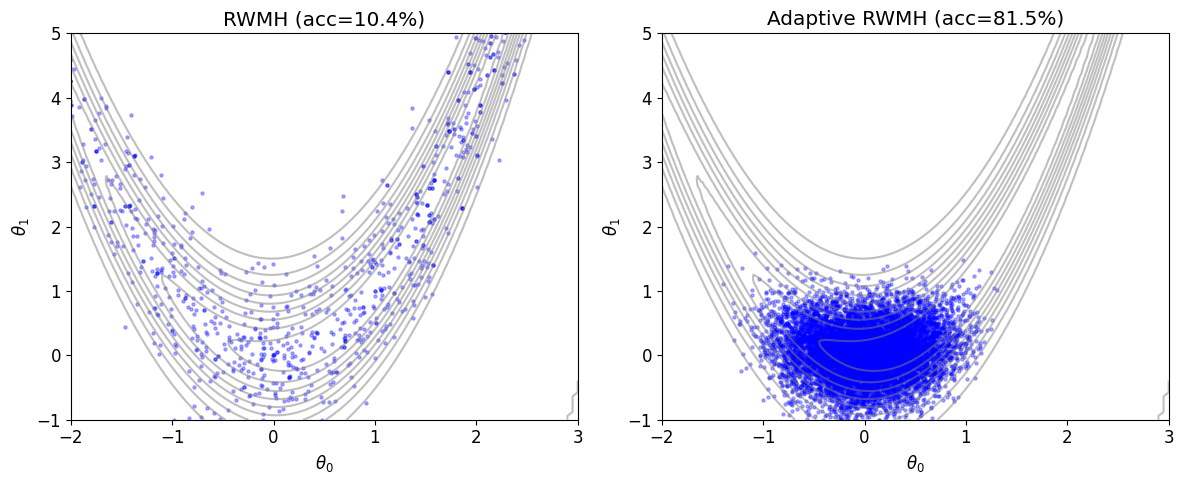

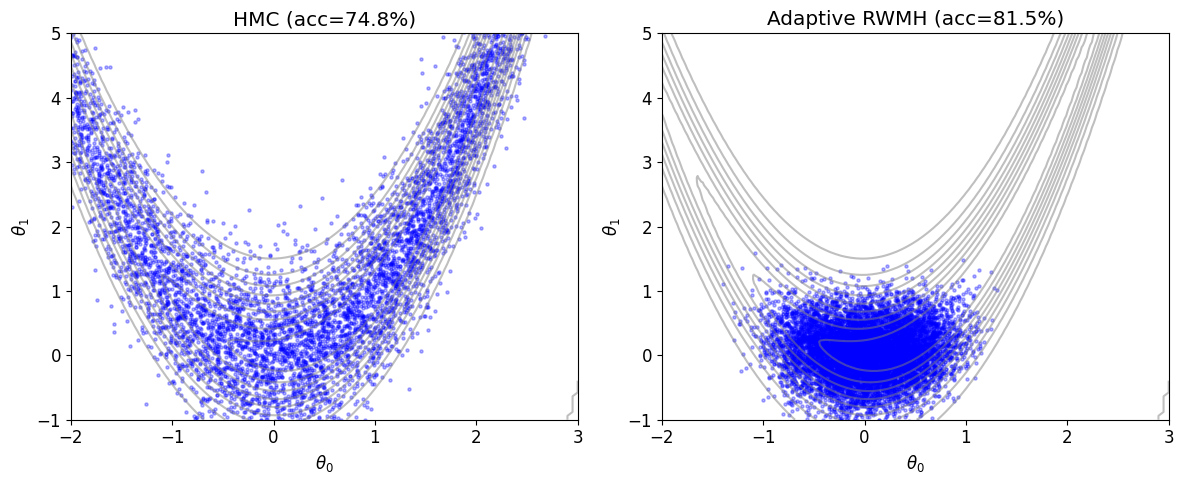

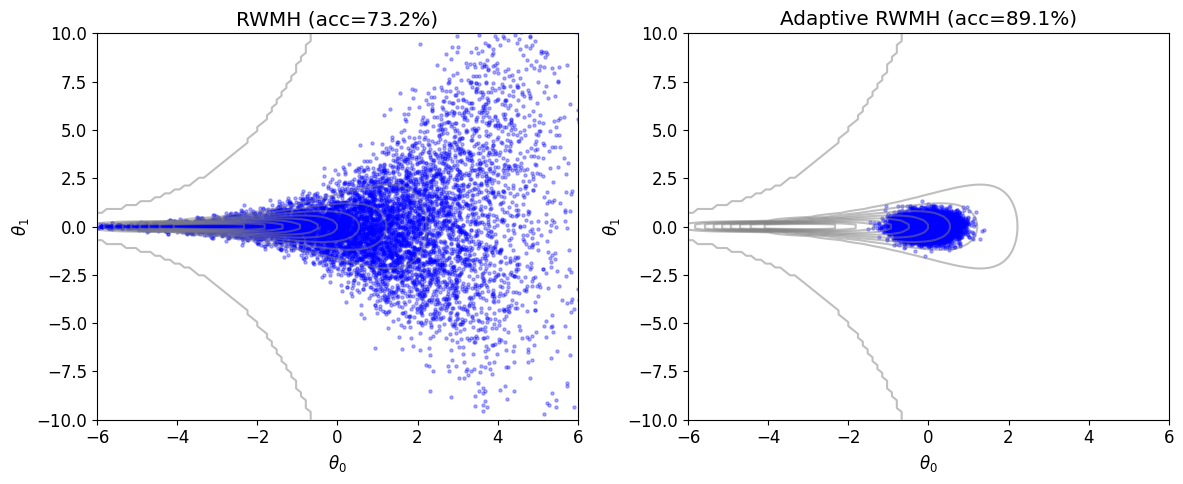

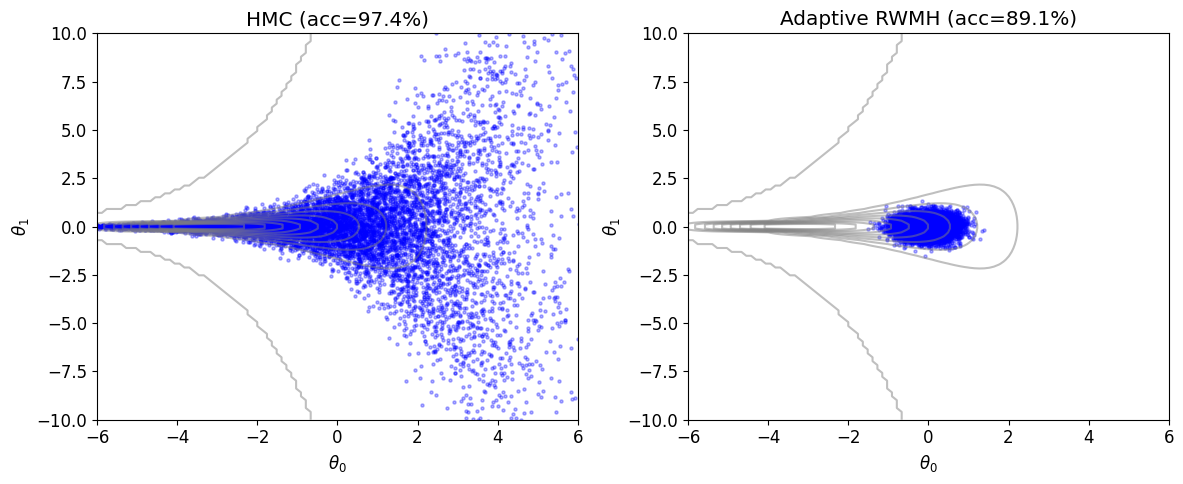

In [28]:
# --- Compare with baselines ---
plot_samples_comparison(
    rwmh_samples, ad_ros_samples,
    f"RWMH (acc={rwmh_acc:.1%})",
    f"Adaptive RWMH (acc={ad_ros_acc:.1%})",
    log_prob_rosenbrock, xlim=(-2, 3), ylim=(-1, 5),
)
plot_samples_comparison(
    hmc_samples, ad_ros_samples,
    f"HMC (acc={hmc_acc:.1%})",
    f"Adaptive RWMH (acc={ad_ros_acc:.1%})",
    log_prob_rosenbrock, xlim=(-2, 3), ylim=(-1, 5),
)
plot_samples_comparison(
    rwmh_funnel_samples, ad_fun_samples,
    f"RWMH (acc={rwmh_funnel_acc:.1%})",
    f"Adaptive RWMH (acc={ad_fun_acc:.1%})",
    log_prob_funnel, xlim=(-6, 6), ylim=(-10, 10),
)
plot_samples_comparison(
    hmc_funnel_samples, ad_fun_samples,
    f"HMC (acc={hmc_funnel_acc:.1%})",
    f"Adaptive RWMH (acc={ad_fun_acc:.1%})",
    log_prob_funnel, xlim=(-6, 6), ylim=(-10, 10),
)


In [29]:
# --- Summary statistics & ESS: all three samplers side by side ---
rosenbrock_var_names = ["x", "y"]
funnel_var_names = ["v", "x"]

summarize_sampler(rwmh_samples, "RWMH - Rosenbrock", rosenbrock_var_names)
summarize_sampler(hmc_samples, "HMC - Rosenbrock", rosenbrock_var_names)
summarize_sampler(ad_ros_samples, "Adaptive RWMH - Rosenbrock", rosenbrock_var_names)

summarize_sampler(rwmh_funnel_samples, "RWMH - Funnel", funnel_var_names)
summarize_sampler(hmc_funnel_samples, "HMC - Funnel", funnel_var_names)
summarize_sampler(ad_fun_samples, "Adaptive RWMH - Funnel", funnel_var_names)



=== RWMH - Rosenbrock ===


,mean,sd,hdi_3%,hdi_97%
x,5.555,2.141,0.706,8.087
y,35.447,17.237,-0.248,58.602



Effective Sample Size (ESS):


<xarray.Dataset> Size: 16B
Dimensions:  ()
Data variables:
    x        float64 8B 1.545
    y        float64 8B 1.544
Attributes:
    created_at:     2026-10-05T08:57:01.208176+00:00
    arviz_version:  0.22.0


=== HMC - Rosenbrock ===


...

<xarray.Dataset> Size: 16B
Dimensions:  ()
Data variables:
    v        float64 8B 208.6
    x        float64 8B 152.6
Attributes:
    created_at:     2026-10-05T08:57:01.955160+00:00
    arviz_version:  0.22.0


=== Adaptive RWMH - Funnel ===


,mean,sd,hdi_3%,hdi_97%
v,-0.060,0.376,-0.765,0.639
x,0.001,0.353,-0.664,0.666



Effective Sample Size (ESS):


<xarray.Dataset> Size: 16B
Dimensions:  ()
Data variables:
    v        float64 8B 3.448e+04
    x        float64 8B 4.384e+04
Attributes:
    created_at:     2026-10-05T08:57:02.042836+00:00
    arviz_version:  0.22.0

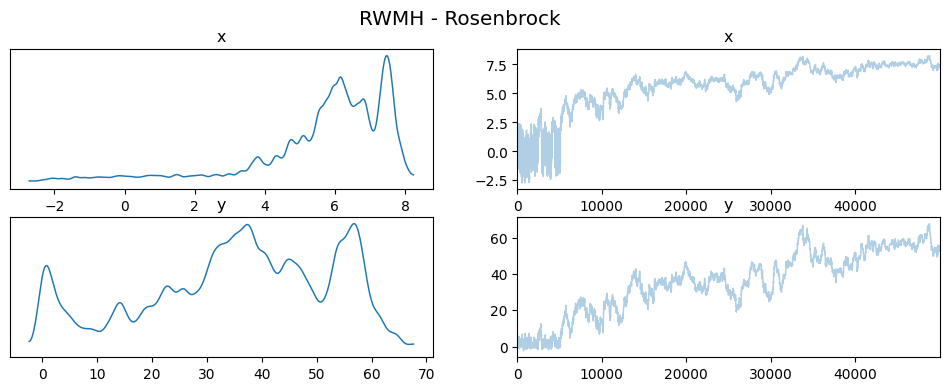

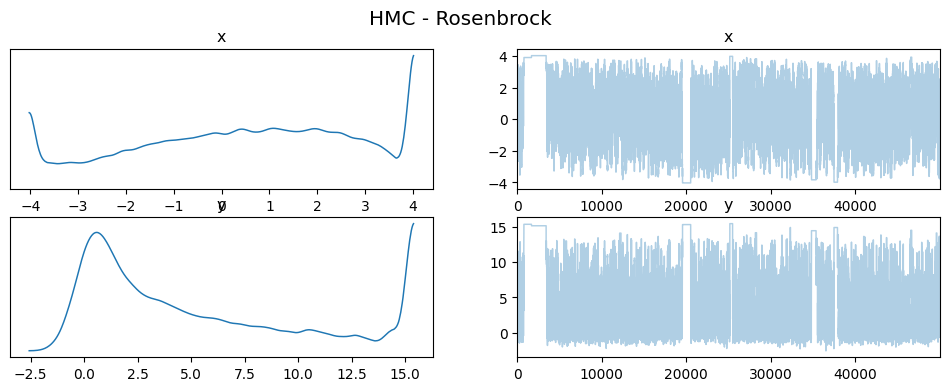

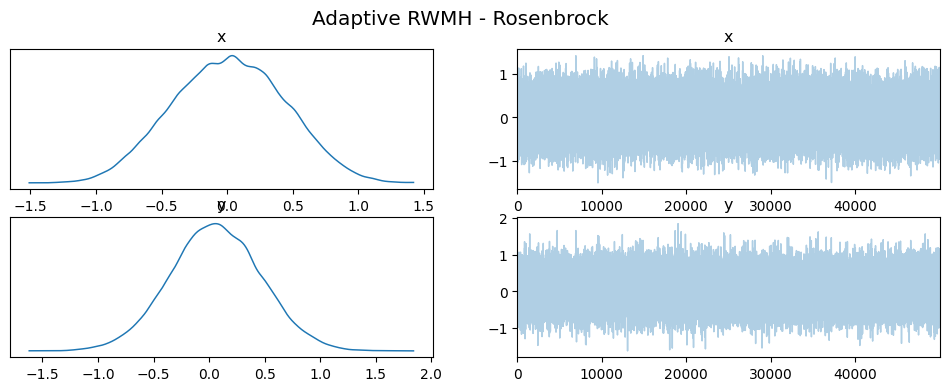

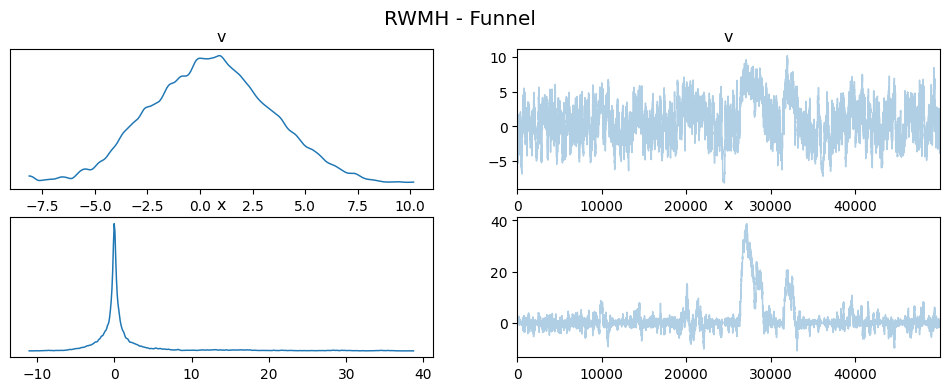

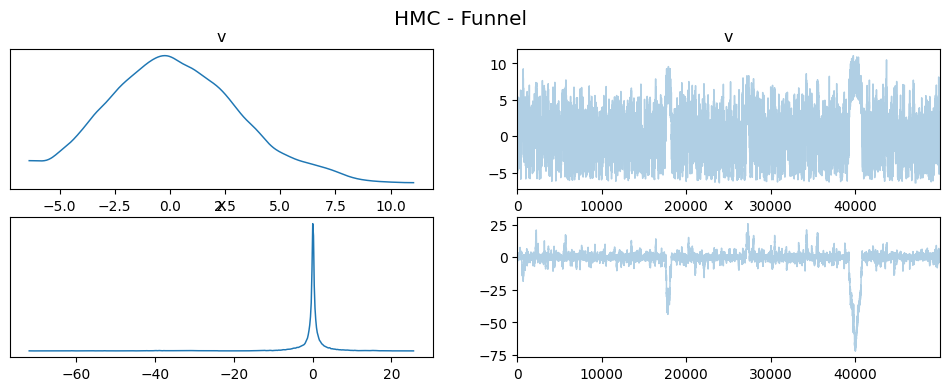

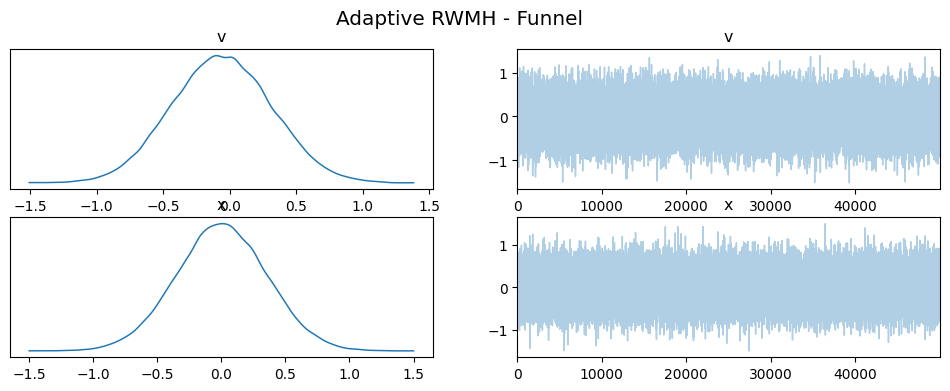

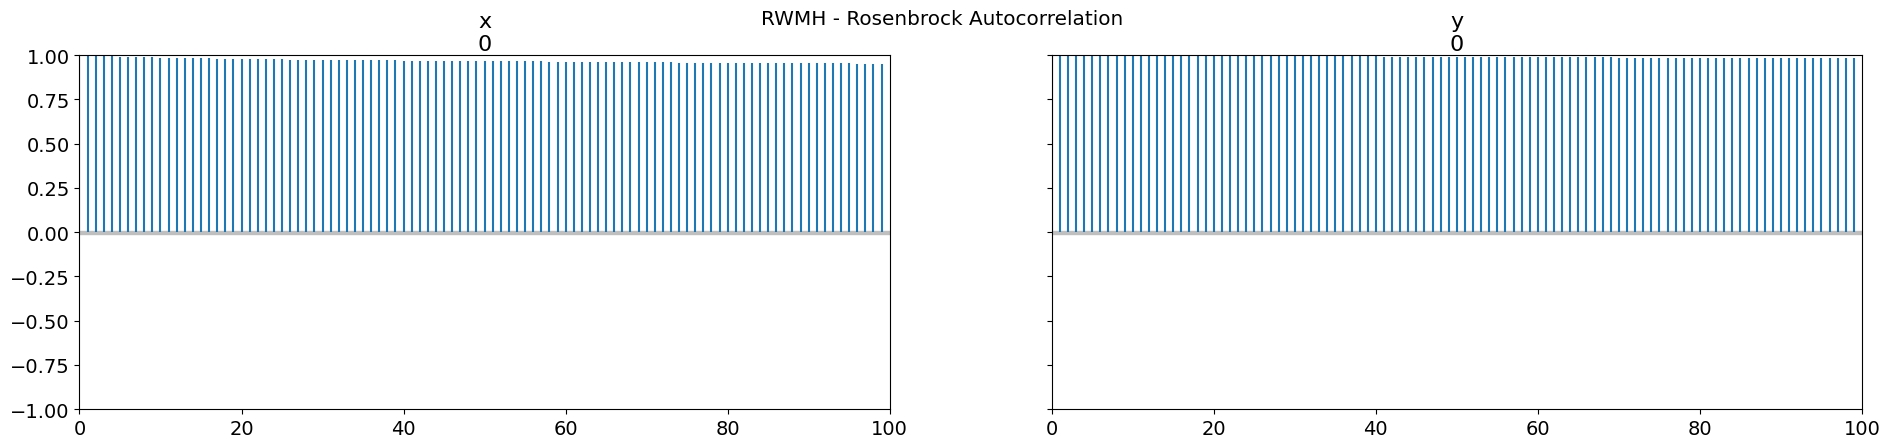

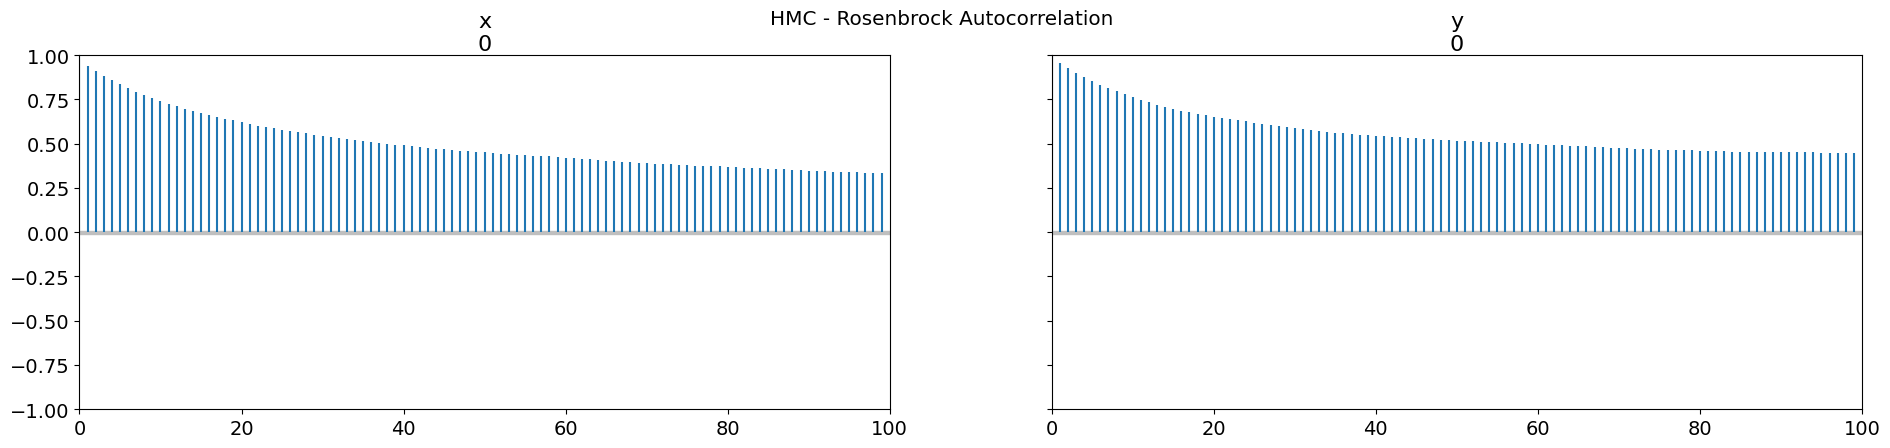

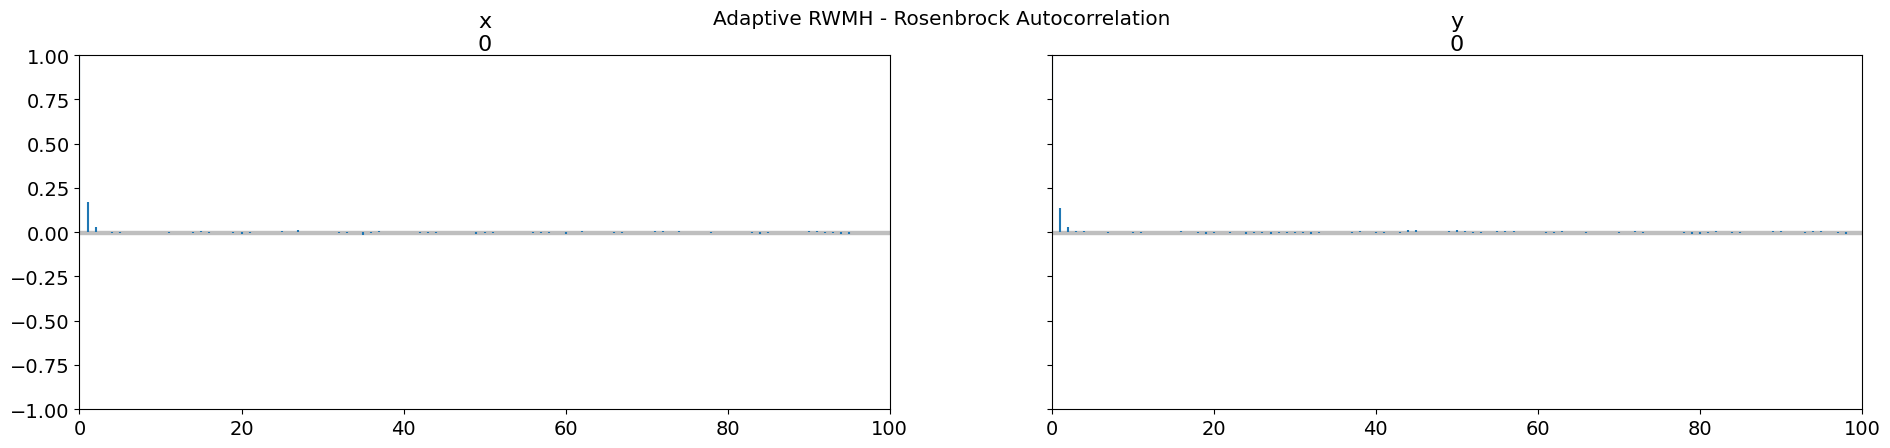

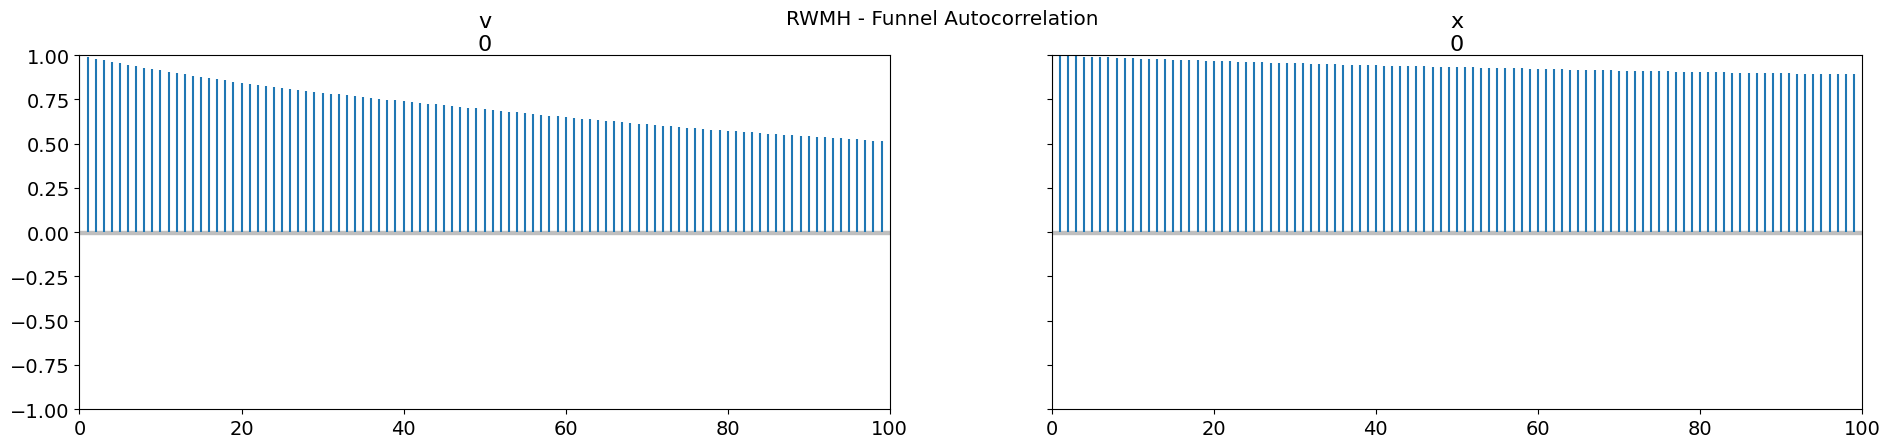

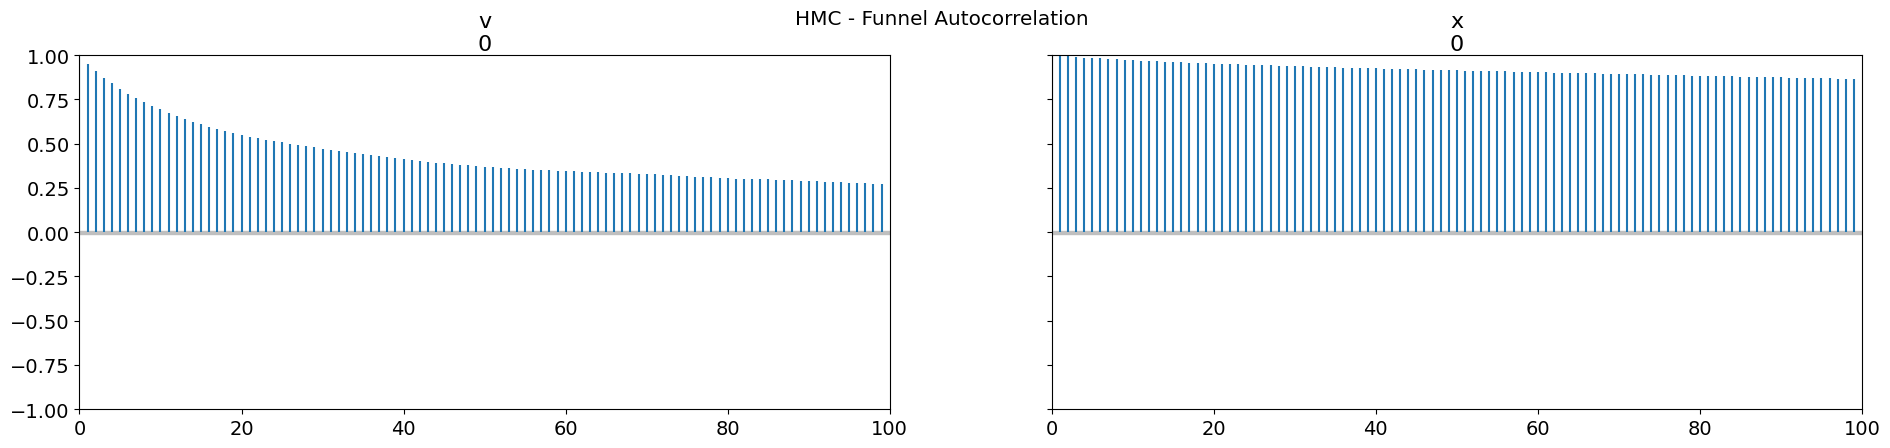

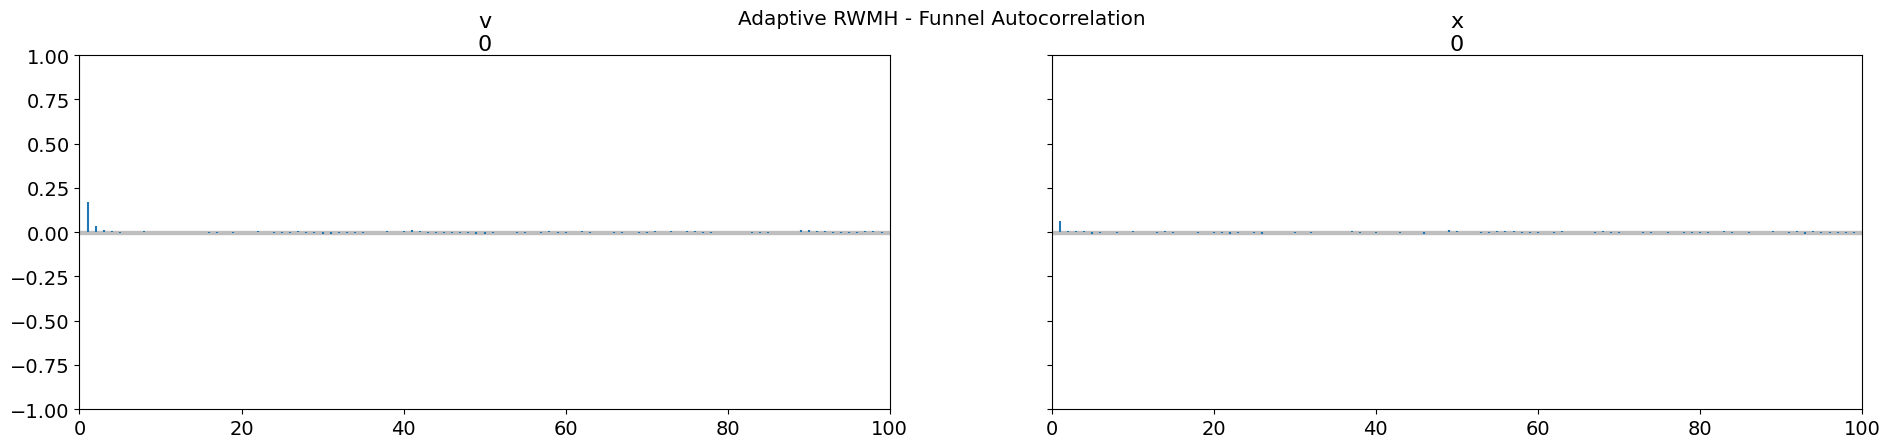

In [30]:
# --- Build InferenceData, trace plots and autocorrelation ---
rwmh_idata = samples_to_inference_data(rwmh_samples, rosenbrock_var_names)
hmc_idata = samples_to_inference_data(hmc_samples, rosenbrock_var_names)
ad_ros_idata = samples_to_inference_data(ad_ros_samples, rosenbrock_var_names)
rwmh_funnel_idata = samples_to_inference_data(rwmh_funnel_samples, funnel_var_names)
hmc_funnel_idata = samples_to_inference_data(hmc_funnel_samples, funnel_var_names)
ad_fun_idata = samples_to_inference_data(ad_fun_samples, funnel_var_names)

# Trace plots
for idata, title in [
    (rwmh_idata, "RWMH - Rosenbrock"),
    (hmc_idata, "HMC - Rosenbrock"),
    (ad_ros_idata, "Adaptive RWMH - Rosenbrock"),
    (rwmh_funnel_idata, "RWMH - Funnel"),
    (hmc_funnel_idata, "HMC - Funnel"),
    (ad_fun_idata, "Adaptive RWMH - Funnel"),
]:
    az.plot_trace(idata)
    plt.suptitle(title)
    plt.show()

# Autocorrelation
for idata, title in [
    (rwmh_idata, "RWMH - Rosenbrock"),
    (hmc_idata, "HMC - Rosenbrock"),
    (ad_ros_idata, "Adaptive RWMH - Rosenbrock"),
    (rwmh_funnel_idata, "RWMH - Funnel"),
    (hmc_funnel_idata, "HMC - Funnel"),
    (ad_fun_idata, "Adaptive RWMH - Funnel"),
]:
    az.plot_autocorr(idata)
    plt.suptitle(title + " Autocorrelation")
    plt.show()


---
### Ablation: sensitivity to the target acceptance rate

The key hyperparameter of Adaptive RWMH is the target acceptance rate
`target_acc`. It controls how aggressive the sampler is: a high target forces a
small conservative step (high acceptance, less per-step progress), a low target
allows larger jumps (lower acceptance). We sweep `target_acc` on Rosenbrock and
record the tuned sigma, achieved acceptance rate and ESS.

In [31]:
for target in [0.60, 0.70, 0.80, 0.90]:
    key = jr.PRNGKey(42)
    samples, acc, sig = run_rwmh_adaptive(
        key, log_prob_rosenbrock, initial_pos,
        sigma0=1.0, n_warmup=1000, n_samples=20_000, target_acc=target,
    )
    idata = samples_to_inference_data(samples, ["x", "y"])
    ess = az.ess(idata)
    print(
        f"target_acc={target:.2f}: acceptance={acc:.1%}, tuned sigma={sig:.3f}, "
        f"ESS_x={float(ess['x'].values):.0f}, ESS_y={float(ess['y'].values):.0f}"
    )


target_acc=0.60: acceptance=58.0%, tuned sigma=0.839, ESS_x=8570, ESS_y=9690
target_acc=0.70: acceptance=71.2%, tuned sigma=0.637, ESS_x=11630, ESS_y=12678
target_acc=0.80: acceptance=79.4%, tuned sigma=0.516, ESS_x=13286, ESS_y=14384
target_acc=0.90: acceptance=88.3%, tuned sigma=0.384, ESS_x=15469, ESS_y=16761
